# LUNA Event Exploration

## Research Context

This case examines what can happen when stress in one stablecoin spreads to the broader crypto market.

TerraUSD (UST) was a stablecoin designed to maintain a value close to **$1**. In May 2022, UST lost that value and the wider Terra ecosystem collapsed.

In the scenario modelled in this project, incoming volatile crypto payments are converted into **USDT** to reduce direct exposure to BTC and ETH price movements.

This raises an important question:

> **If funds have already been converted into USDT, can a major failure of another stablecoin still affect the value of the operational balance?**

The analysis therefore uses two layers:

1. **BTC and ETH — broader market context**  
   These assets show how severe the wider crypto-market stress became during the LUNA collapse.

2. **USDT — modelled operational balance**  
   USDT is examined to determine whether the balance remained close to its intended $1 value during the event.

**USDC is used as a comparison stablecoin** to help distinguish broader stablecoin-market stress from movements specific to USDT.

This case is used to examine **stablecoin contagion and peg risk**.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt


## 1. Daily Market Context

The LUNA crisis developed over several days rather than as a single isolated market move.

The daily analysis first examines BTC and ETH to understand what was happening in the broader crypto market around the collapse.

The purpose is to establish the market environment before moving to the stablecoin balance itself.

In [2]:
crypto_daily_processed = pd.read_csv('../data/processed/daily/crypto_daily_processed.csv', parse_dates=["date"])
crypto_daily_processed.head()

,date,btc_close,eth_close,usdc_close,usdt_close,btc_high,eth_high,usdc_high,usdt_high,btc_low,...,usdc_low,usdt_low,btc_open,eth_open,usdc_open,usdt_open,btc_volume,eth_volume,usdc_volume,usdt_volume
0,2020-01-01,7200.174316,130.802002,1.004079,0.999836,7254.330566,132.835358,1.006639,1.006873,7174.944336,...,1.001989,0.994924,7194.892090,129.630661,1.003730,0.999571,1.856566e+10,7.935230e+09,242586528.0,2.150314e+10
1,2020-01-02,6985.470215,127.410179,1.005017,1.001565,7212.155273,130.820038,1.012636,1.008451,6935.270020,...,1.002543,0.986515,7202.551270,130.820038,1.004431,0.999788,2.080208e+10,8.032709e+09,318268134.0,2.421231e+10
2,2020-01-03,7344.884277,134.171707,1.005273,1.004192,7413.715332,134.554016,1.007928,1.022286,6914.996094,...,0.988455,0.988027,6984.428711,127.411263,1.005357,1.001183,2.811148e+10,1.047685e+10,374792167.0,3.242029e+10
3,2020-01-04,7410.656738,135.069366,1.009466,1.007472,7427.385742,136.052719,1.018391,1.013633,7309.514160,...,1.001273,0.999160,7345.375488,134.168518,1.004818,1.003510,1.844427e+10,7.430905e+09,334494308.0,2.158563e+10
4,2020-01-05,7411.317383,136.276779,1.008497,1.006197,7544.497070,139.410202,1.018718,1.016161,7400.535645,...,1.003932,1.001758,7410.451660,135.072098,1.008748,1.009921,1.972507e+10,7.526675e+09,334597544.0,2.409014e+10


In [3]:
luna_daily = crypto_daily_processed[
    (crypto_daily_processed["date"] >= "2022-05-05") &
    (crypto_daily_processed["date"] <= "2022-05-15")
]
luna_daily

,date,btc_close,eth_close,usdc_close,usdt_close,btc_high,eth_high,usdc_high,usdt_high,btc_low,...,usdc_low,usdt_low,btc_open,eth_open,usdc_open,usdt_open,btc_volume,eth_volume,usdc_volume,usdt_volume
855,2022-05-05,36575.140625,2749.213135,0.999958,0.999988,39789.281250,2948.960693,1.000605,1.000197,35856.515625,...,0.999381,0.999920,39695.746094,2940.226562,1.000066,1.000039,4.310626e+10,2.264293e+10,5.202645e+09,8.567964e+10
856,2022-05-06,36040.921875,2694.979736,1.000072,0.999982,36624.359375,2754.837646,1.000608,1.000215,35482.132812,...,0.999523,0.999916,36573.183594,2748.931641,0.999947,0.999990,3.779558e+10,2.102760e+10,5.376284e+09,8.132788e+10
857,2022-05-07,35501.953125,2636.093018,0.999906,0.999921,36129.925781,2696.652832,1.000427,1.000049,34940.824219,...,0.999617,0.999774,36042.503906,2694.991943,1.000065,0.999971,2.437590e+10,1.336928e+10,3.623127e+09,5.720259e+10
858,2022-05-08,34059.265625,2517.459961,1.000087,0.999854,35502.941406,2638.830566,1.000631,1.000063,33878.964844,...,0.999548,0.999740,35502.941406,2636.121826,0.999918,0.999919,3.676304e+10,2.080227e+10,5.432001e+09,7.790016e+10
859,2022-05-09,30296.953125,2245.430420,0.999595,0.999909,34222.074219,2528.258057,1.000682,1.000134,30296.953125,...,0.999376,0.999770,34060.015625,2518.508301,0.999994,0.999870,6.335549e+10,3.633357e+10,8.493986e+09,1.207103e+11
860,2022-05-10,31022.906250,2343.510986,0.999828,0.999791,32596.308594,2450.760254,1.000685,1.000134,29944.802734,...,0.999278,0.999709,30273.654297,2242.650391,0.999576,0.999945,5.981104e+10,3.820210e+10,8.611992e+09,1.286921e+11
861,2022-05-11,28936.355469,2072.108643,1.000766,0.995872,32013.402344,2441.079346,1.001350,0.999996,28170.414062,...,0.999253,0.993459,31016.183594,2342.754150,0.999785,0.999790,7.038886e+10,4.574340e+10,1.514329e+10,1.597004e+11
862,2022-05-12,29047.751953,1961.701538,1.000659,0.997609,30032.439453,2170.458008,1.011434,0.997736,26350.490234,...,0.999531,0.948486,28936.734375,2072.504639,1.000777,0.995879,6.698917e+10,4.246349e+10,1.861205e+10,1.410528e+11
863,2022-05-13,29283.103516,2014.418213,1.000347,0.998239,30924.802734,2139.713379,1.001901,0.999193,28782.330078,...,0.999637,0.996945,29030.910156,1960.122559,1.000601,0.997527,4.284112e+10,2.481610e+10,8.025797e+09,8.700989e+10
864,2022-05-14,30101.265625,2056.273926,1.000381,0.998780,30192.802734,2063.429932,1.000977,0.998971,28702.910156,...,0.999695,0.997791,29285.642578,2014.280640,1.000418,0.998242,2.857987e+10,1.545704e+10,5.734214e+09,6.078188e+10


In [4]:
luna_daily[["date", "btc_close", "eth_close"]]

,date,btc_close,eth_close
855,2022-05-05,36575.140625,2749.213135
856,2022-05-06,36040.921875,2694.979736
857,2022-05-07,35501.953125,2636.093018
858,2022-05-08,34059.265625,2517.459961
859,2022-05-09,30296.953125,2245.430420
860,2022-05-10,31022.906250,2343.510986
861,2022-05-11,28936.355469,2072.108643
862,2022-05-12,29047.751953,1961.701538
863,2022-05-13,29283.103516,2014.418213
864,2022-05-14,30101.265625,2056.273926


In [5]:
luna_daily = luna_daily.copy()

luna_daily["btc_return_pct"] = (luna_daily["btc_close"].pct_change() * 100)

luna_daily["eth_return_pct"] = (luna_daily["eth_close"].pct_change() * 100)
luna_daily[["date", "btc_close", "eth_close", "btc_return_pct", "eth_return_pct"]]

,date,btc_close,eth_close,btc_return_pct,eth_return_pct
855,2022-05-05,36575.140625,2749.213135,NaN,NaN
856,2022-05-06,36040.921875,2694.979736,-1.460606,-1.972688
857,2022-05-07,35501.953125,2636.093018,-1.495436,-2.185052
858,2022-05-08,34059.265625,2517.459961,-4.063685,-4.500337
859,2022-05-09,30296.953125,2245.430420,-11.046370,-10.805715
860,2022-05-10,31022.906250,2343.510986,2.396126,4.368007
861,2022-05-11,28936.355469,2072.108643,-6.725839,-11.581014
862,2022-05-12,29047.751953,1961.701538,0.384971,-5.328249
863,2022-05-13,29283.103516,2014.418213,0.810223,2.687293
864,2022-05-14,30101.265625,2056.273926,2.793973,2.077807


In [6]:
luna_daily[["date", "btc_close", "eth_close", "btc_return_pct", "eth_return_pct"]].sort_values(by='btc_return_pct').head()

,date,btc_close,eth_close,btc_return_pct,eth_return_pct
859,2022-05-09,30296.953125,2245.430420,-11.046370,-10.805715
861,2022-05-11,28936.355469,2072.108643,-6.725839,-11.581014
858,2022-05-08,34059.265625,2517.459961,-4.063685,-4.500337
857,2022-05-07,35501.953125,2636.093018,-1.495436,-2.185052
856,2022-05-06,36040.921875,2694.979736,-1.460606,-1.972688


In [7]:
luna_daily[["date", "btc_close", "eth_close", "btc_return_pct", "eth_return_pct"]].sort_values(by='eth_return_pct').head()

,date,btc_close,eth_close,btc_return_pct,eth_return_pct
861,2022-05-11,28936.355469,2072.108643,-6.725839,-11.581014
859,2022-05-09,30296.953125,2245.430420,-11.046370,-10.805715
862,2022-05-12,29047.751953,1961.701538,0.384971,-5.328249
858,2022-05-08,34059.265625,2517.459961,-4.063685,-4.500337
857,2022-05-07,35501.953125,2636.093018,-1.495436,-2.185052


Text(0, 0.5, 'BTC Price (USD)')

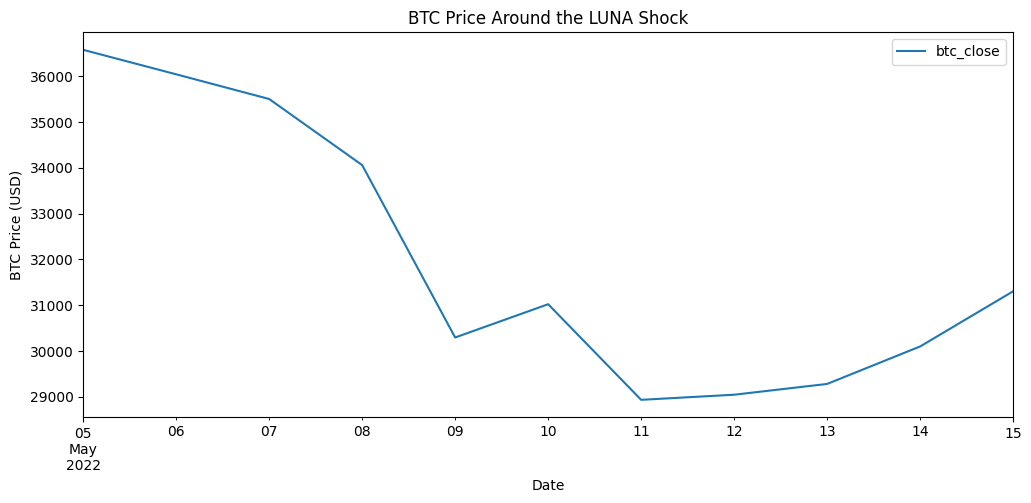

In [8]:
ax = luna_daily.plot(
    x="date",
    y="btc_close",
    figsize=(12, 5),
    title="BTC Price Around the LUNA Shock"
)

ax.set_xlabel("Date")
ax.set_ylabel("BTC Price (USD)")

Text(0, 0.5, 'Daily Return (%)')

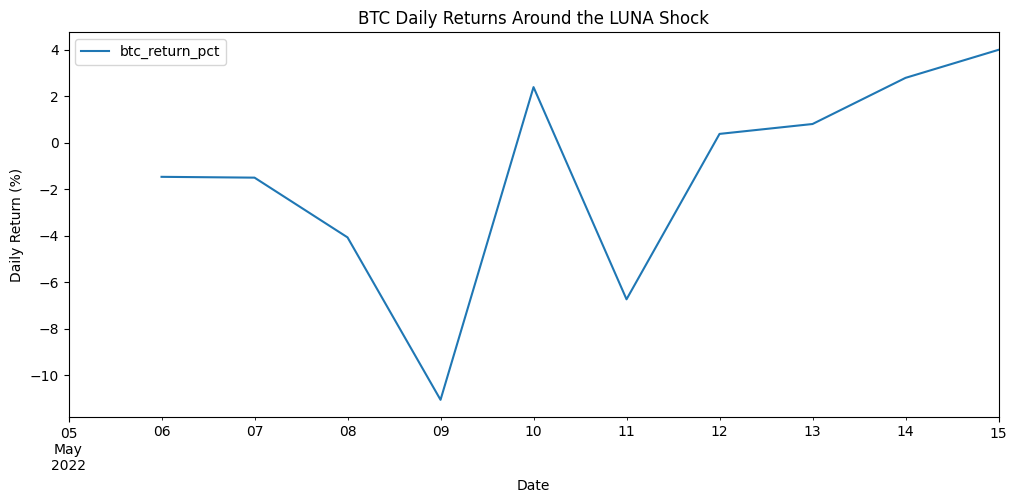

In [9]:
ax = luna_daily.plot(
    x="date",
    y="btc_return_pct",
    figsize=(12, 5),
    title="BTC Daily Returns Around the LUNA Shock"
)

ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")

Text(0, 0.5, 'ETH Price (USD)')

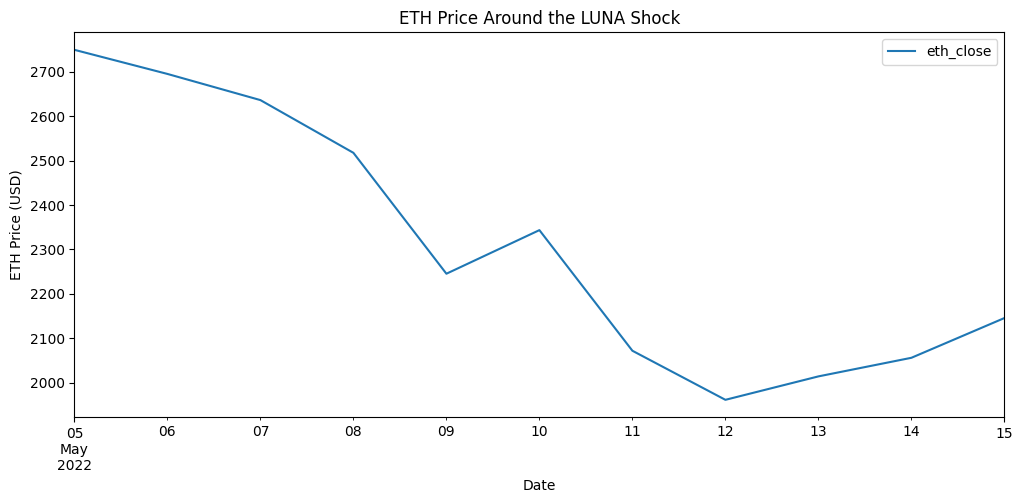

In [10]:
ax = luna_daily.plot(
    x="date",
    y="eth_close",
    figsize=(12, 5),
    title="ETH Price Around the LUNA Shock"
)

ax.set_xlabel("Date")
ax.set_ylabel("ETH Price (USD)")

Text(0, 0.5, 'Daily Return (%)')

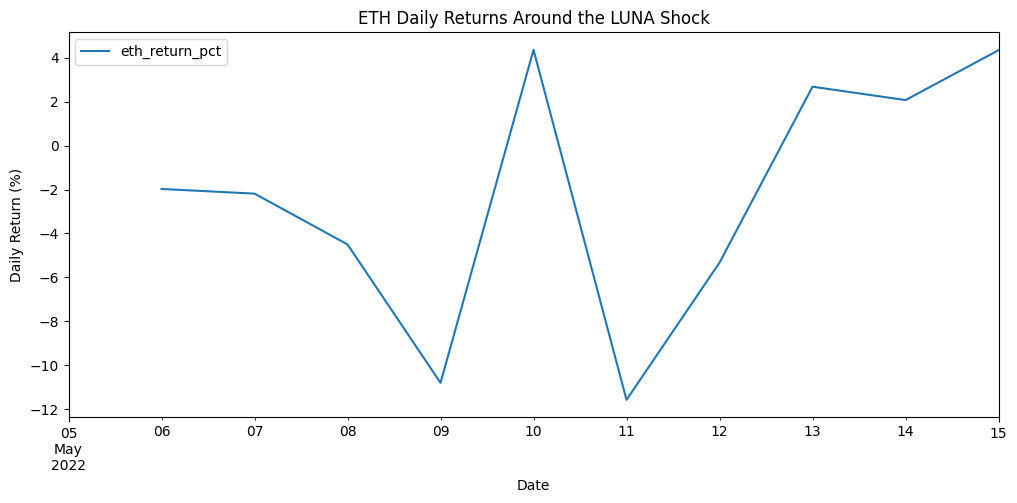

In [11]:
ax = luna_daily.plot(
    x="date",
    y="eth_return_pct",
    figsize=(12, 5),
    title="ETH Daily Returns Around the LUNA Shock"
)

ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")

### Daily Observation

BTC and ETH were already declining before the main LUNA sell-off, but market stress intensified substantially during the event period.

BTC recorded its largest daily decline in the selected window on **9 May**, while ETH recorded its largest decline on **11 May**.

This shows that the crisis developed across several days rather than as a single one-time market shock.

The daily data is used here only to describe the broader market environment. The next step examines the timing of this stress in more detail using hourly data.

## 2. Hourly Market Stress

The daily data shows that the market decline developed over several days.

Hourly BTC and ETH data provides a more detailed view of how market stress evolved around the early phase of the LUNA collapse.

The purpose is not to assume that every hourly movement was caused by LUNA, but to understand where the identifiable event sits within the broader period of crypto-market stress.

In [12]:
btc_luna_hourly = pd.read_csv('../data/processed/hourly/binance/btc_luna_hourly_processed.csv', parse_dates=["open_time"])
btc_luna_hourly.head()

,open_time,open,high,low,close,volume
0,2022-04-25 00:00:00,39450.12,39500.84,38674.00,38855.47,4228.78013
1,2022-04-25 01:00:00,38855.47,39154.38,38747.51,39095.81,2336.46392
2,2022-04-25 02:00:00,39095.81,39153.94,38961.64,39091.17,1205.51583
3,2022-04-25 03:00:00,39091.17,39294.76,39086.37,39253.71,1443.33178
4,2022-04-25 04:00:00,39253.70,39256.28,39055.71,39139.74,896.85541


In [13]:
luna_btc_detail = btc_luna_hourly[
    (btc_luna_hourly["open_time"] >= "2022-05-05") &
    (btc_luna_hourly["open_time"] < "2022-05-11")
].copy()

In [14]:
luna_btc_detail["btc_hourly_return_pct"] = (luna_btc_detail["close"].pct_change() * 100)
luna_btc_detail[["open_time", "close", "btc_hourly_return_pct"]]

,open_time,close,btc_hourly_return_pct
240,2022-05-05 00:00:00,39661.34,NaN
241,2022-05-05 01:00:00,39629.70,-0.079775
242,2022-05-05 02:00:00,39773.33,0.362430
243,2022-05-05 03:00:00,39729.41,-0.110426
244,2022-05-05 04:00:00,39752.93,0.059200
...,...,...,...
379,2022-05-10 19:00:00,31330.03,-0.931176
380,2022-05-10 20:00:00,31009.27,-1.023810
381,2022-05-10 21:00:00,30239.04,-2.483870
382,2022-05-10 22:00:00,30785.18,1.806076


In [15]:
luna_btc_detail[["open_time", "close", "btc_hourly_return_pct"]].sort_values(by='btc_hourly_return_pct').head()

,open_time,close,btc_hourly_return_pct
255,2022-05-05 15:00:00,36909.67,-3.400586
359,2022-05-09 23:00:00,30076.31,-3.253936
381,2022-05-10 21:00:00,30239.04,-2.483870
374,2022-05-10 14:00:00,31085.34,-2.295811
309,2022-05-07 21:00:00,35026.37,-2.121854


Text(0, 0.5, 'BTC Price (USDT)')

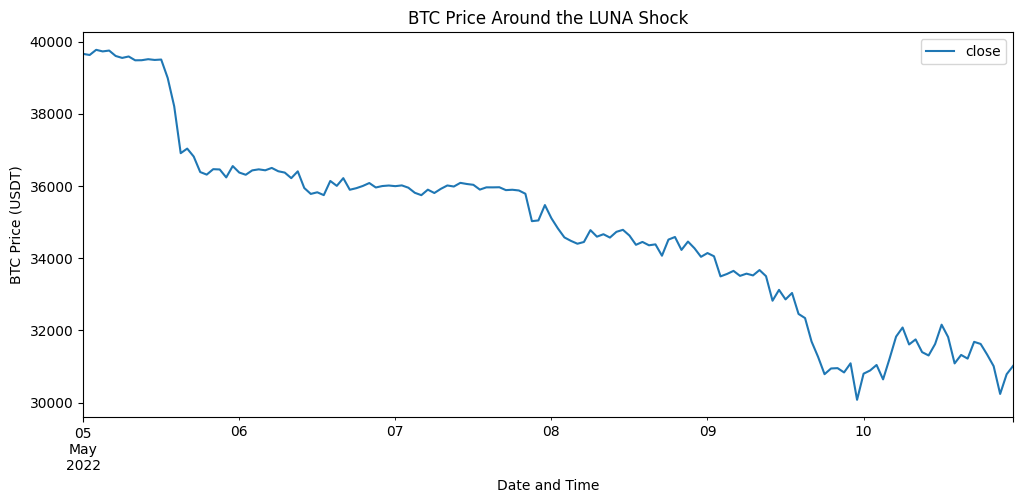

In [16]:
ax = luna_btc_detail.plot(
    x="open_time",
    y="close",
    figsize=(12, 5),
    title="BTC Price Around the LUNA Shock"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("BTC Price (USDT)")

Text(0, 0.5, 'BTC Hourly Returns (%)')

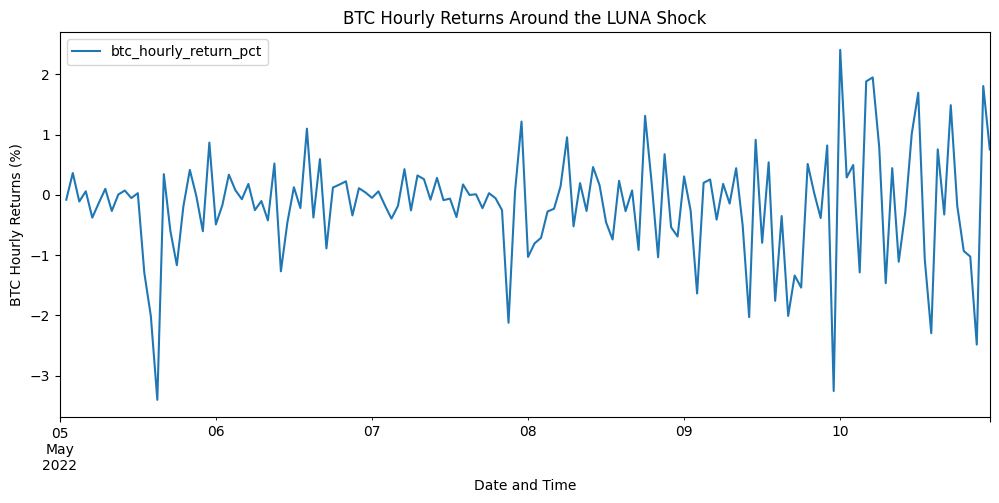

In [17]:
ax = luna_btc_detail.plot(
    x="open_time",
    y="btc_hourly_return_pct",
    figsize=(12, 5),
    title="BTC Hourly Returns Around the LUNA Shock"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("BTC Hourly Returns (%)")

In [18]:
eth_luna_hourly = pd.read_csv('../data/processed/hourly/binance/eth_luna_hourly_processed.csv', parse_dates=["open_time"])
eth_luna_hourly.head()

,open_time,open,high,low,close,volume
0,2022-04-25 00:00:00,2920.99,2925.75,2851.40,2856.55,54637.7153
1,2022-04-25 01:00:00,2856.55,2868.97,2841.60,2865.04,24748.3526
2,2022-04-25 02:00:00,2865.03,2869.45,2853.18,2860.44,14716.0350
3,2022-04-25 03:00:00,2860.43,2879.72,2860.00,2875.59,11779.1677
4,2022-04-25 04:00:00,2875.58,2876.00,2863.38,2864.99,13012.4532


In [19]:
luna_eth_detail = eth_luna_hourly[
    (eth_luna_hourly["open_time"] >= "2022-05-05") &
    (eth_luna_hourly["open_time"] < "2022-05-11")
].copy()

In [20]:
luna_eth_detail["eth_hourly_return_pct"] = (luna_eth_detail["close"].pct_change() * 100)
luna_eth_detail[["open_time", "close", "eth_hourly_return_pct"]]

,open_time,close,eth_hourly_return_pct
240,2022-05-05 00:00:00,2942.99,NaN
241,2022-05-05 01:00:00,2940.86,-0.072375
242,2022-05-05 02:00:00,2947.49,0.225444
243,2022-05-05 03:00:00,2941.60,-0.199831
244,2022-05-05 04:00:00,2945.45,0.130881
...,...,...,...
379,2022-05-10 19:00:00,2354.28,-0.975407
380,2022-05-10 20:00:00,2328.64,-1.089080
381,2022-05-10 21:00:00,2263.91,-2.779734
382,2022-05-10 22:00:00,2320.16,2.484639


In [21]:
luna_eth_detail[["open_time", "close", "eth_hourly_return_pct"]].sort_values(by='eth_hourly_return_pct').head()

,open_time,close,eth_hourly_return_pct
255,2022-05-05 15:00:00,2742.85,-3.093887
359,2022-05-09 23:00:00,2228.55,-2.826408
374,2022-05-10 14:00:00,2357.89,-2.797886
346,2022-05-09 10:00:00,2377.60,-2.782889
381,2022-05-10 21:00:00,2263.91,-2.779734


Text(0, 0.5, 'ETH Price (USDT)')

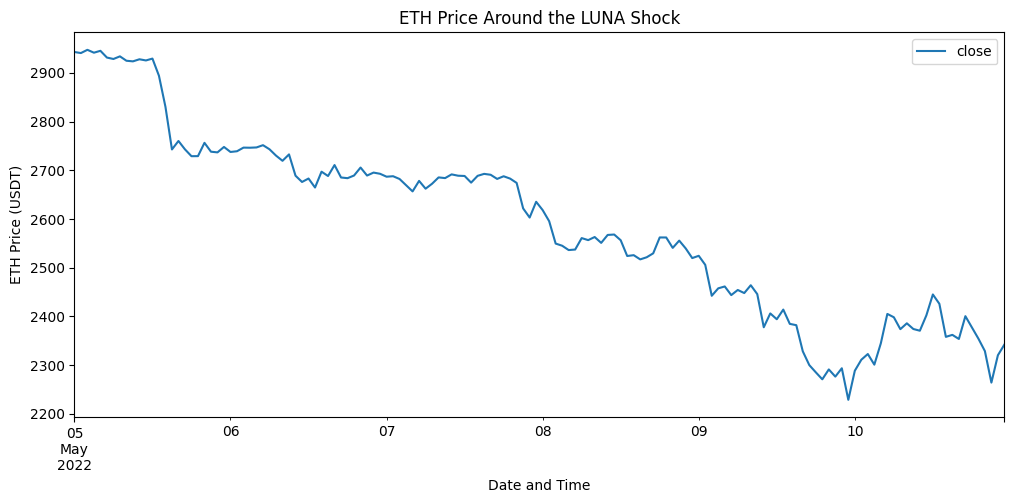

In [22]:
ax = luna_eth_detail.plot(
    x="open_time",
    y="close",
    figsize=(12, 5),
    title="ETH Price Around the LUNA Shock"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("ETH Price (USDT)")

Text(0, 0.5, 'ETH Hourly Returns (%)')

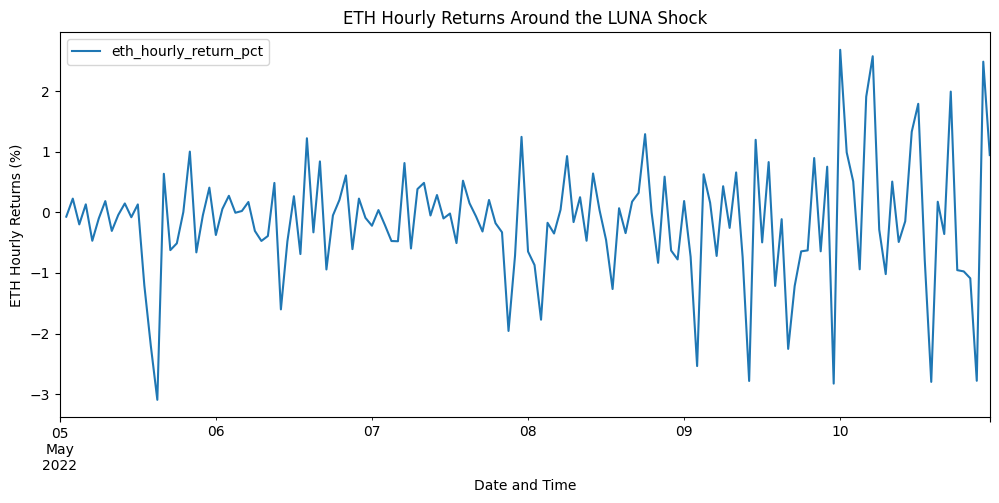

In [23]:
ax = luna_eth_detail.plot(
    x="open_time",
    y="eth_hourly_return_pct",
    figsize=(12, 5),
    title="ETH Hourly Returns Around the LUNA Shock"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("ETH Hourly Returns (%)")

### Hourly Observation

The hourly data confirms that BTC and ETH were already experiencing substantial negative movements before the selected LUNA event reference point.

Large declines continued during the following days, showing that the market stress developed progressively rather than beginning at one exact hour.

This is important for the event study: `T0` is used as a reference point for analysis, not as a claim that the entire market decline started at that moment.

## 3. Event Timeline and T0 Definition

The LUNA collapse did not begin with one perfectly defined market timestamp.

For this project, **T0 is used as a reference point for comparing observations before and after an identifiable event**.

It does not mean that every later BTC, ETH or stablecoin price movement was caused by that event.

The BTC and ETH analysis shows that the major joint market sell-off occurred on May 9. However, the market reaction does not necessarily represent the beginning of the underlying shock.

External sources indicate that the UST de-pegging process had already started on May 7, 2022.

Jump Crypto's reconstruction of the event shows increasing UST liquidity imbalance during May 7, followed by several large transactions between approximately 21:44 and 22:59 UTC. Chainalysis describes the same sequence of events, including the withdrawal of 150 million UST from Curve's 3pool and subsequent large UST swaps.

Based on this event timeline, **May 7 at 22:00 UTC is selected as the Shock T0 for this case study**.

This timestamp is not intended to represent an exact official start of the LUNA collapse. Instead, it represents a point at which significant UST stress had become observable, while the major BTC and ETH sell-off identified in the market data had not yet occurred.

### Sources

- [Jump Crypto — *The Depegging of UST*](https://jumpcrypto.com/resources/the-depegging-of-ust)
- [Chainalysis — *The Trades That Triggered TerraUSD's Collapse*](https://www.chainalysis.com/blog/how-terrausd-collapsed)
- [Easy Crypto — *Terra LUNA Collapse: The Story*](https://hub.easycrypto.com/news/terra-luna-collapse-story)

In [24]:
t0_shock = pd.Timestamp("2022-05-07 22:00:00", tz="UTC")

## 4. Stablecoin Stability During the LUNA Crisis

BTC and ETH show the broader market stress, but they are not the operational balance being modelled in this project.

In the hypothetical payment scenario, incoming volatile crypto payments have already been converted into **USDT**.

The key question is therefore:

> **Did USDT remain close to its intended $1 value while another major stablecoin was collapsing?**

USDC is included as a comparison asset. If both stablecoins move similarly, the stress may reflect broader market conditions. If one behaves differently, the movement may be more asset-specific.

In [25]:
usdt_luna_hourly = pd.read_csv('../data/processed/hourly/coinbase/usdt_luna_hourly_processed.csv', parse_dates=["timestamp"])
usdt_luna_hourly.head()

,timestamp,low,high,open,close,volume
0,2022-04-25 00:00:00+00:00,0.9256,0.9267,0.9257,0.9262,619290.49
1,2022-04-25 01:00:00+00:00,0.9261,0.9274,0.9262,0.9273,179045.80
2,2022-04-25 02:00:00+00:00,0.9270,0.9280,0.9273,0.9280,80173.86
3,2022-04-25 03:00:00+00:00,0.9273,0.9279,0.9279,0.9278,53284.54
4,2022-04-25 04:00:00+00:00,0.9275,0.9285,0.9278,0.9285,52771.30


In [26]:
usdc_luna_hourly = pd.read_csv('../data/processed/hourly/coinbase/usdc_luna_hourly_processed.csv', parse_dates=["timestamp"])
usdc_luna_hourly.head()

,timestamp,low,high,open,close,volume
0,2022-04-25 00:00:00+00:00,0.9253,0.9261,0.9254,0.9260,397616.79
1,2022-04-25 01:00:00+00:00,0.9259,0.9272,0.9260,0.9270,62165.68
2,2022-04-25 02:00:00+00:00,0.9269,0.9279,0.9270,0.9278,42487.00
3,2022-04-25 03:00:00+00:00,0.9272,0.9277,0.9277,0.9275,24583.10
4,2022-04-25 04:00:00+00:00,0.9274,0.9282,0.9276,0.9281,23136.60


In [27]:
eur_luna_hourly = pd.read_csv('../data/processed/fx/eur_usd_luna_hourly_processed.csv', parse_dates=["timestamp"])
eur_luna_hourly.head()

,timestamp,open,high,low,close,volume
0,2022-04-25 00:00:00+00:00,1.08093,1.08119,1.07998,1.08020,13803420000
1,2022-04-25 01:00:00+00:00,1.08020,1.08044,1.07836,1.07870,15524000000
2,2022-04-25 02:00:00+00:00,1.07871,1.07888,1.07772,1.07812,10004250000
3,2022-04-25 03:00:00+00:00,1.07813,1.07882,1.07799,1.07814,6895050000
4,2022-04-25 04:00:00+00:00,1.07812,1.07853,1.07724,1.07741,6009300000


In [28]:
for name, df in {
    "USDT/EUR": usdt_luna_hourly,
    "USDC/EUR": usdc_luna_hourly,
    "EUR/USD": eur_luna_hourly
}.items():
    print(
        name,
        "| rows:", len(df),
        "| start:", df["timestamp"].min(),
        "| end:", df["timestamp"].max()
    )

USDT/EUR | rows: 721 | start: 2022-04-25 00:00:00+00:00 | end: 2022-05-25 00:00:00+00:00
USDC/EUR | rows: 721 | start: 2022-04-25 00:00:00+00:00 | end: 2022-05-25 00:00:00+00:00
EUR/USD | rows: 552 | start: 2022-04-25 00:00:00+00:00 | end: 2022-05-25 23:00:00+00:00


### Converting EUR Prices to Approximate USD Values

Coinbase quotes USDT and USDC against EUR, while both stablecoins are designed to remain close to **$1**.

To evaluate their peg directly, the EUR prices are combined with the EUR/USD benchmark:

`stablecoin/EUR × EUR/USD = approximate stablecoin/USD`

Without this adjustment, a movement in USDT/EUR or USDC/EUR could partly reflect a change in the EUR/USD exchange rate rather than a movement in the stablecoin itself.

In [29]:
stablecoin_luna = (
    usdt_luna_hourly[["timestamp", "close"]]
    .rename(columns={"close": "usdt_eur_close"})
    .merge(
        usdc_luna_hourly[["timestamp", "close"]]
        .rename(columns={"close": "usdc_eur_close"}),
        on="timestamp",
        how="outer"
    )
)
stablecoin_luna

,timestamp,usdt_eur_close,usdc_eur_close
0,2022-04-25 00:00:00+00:00,0.92620,0.9260
1,2022-04-25 01:00:00+00:00,0.92730,0.9270
2,2022-04-25 02:00:00+00:00,0.92800,0.9278
3,2022-04-25 03:00:00+00:00,0.92780,0.9275
4,2022-04-25 04:00:00+00:00,0.92850,0.9281
...,...,...,...
716,2022-05-24 20:00:00+00:00,0.93083,0.9316
717,2022-05-24 21:00:00+00:00,0.93058,0.9316
718,2022-05-24 22:00:00+00:00,0.93040,0.9312
719,2022-05-24 23:00:00+00:00,0.93066,0.9316


In [30]:
luna_stablecoin_fx = stablecoin_luna.merge(
    eur_luna_hourly[["timestamp", "close"]]
    .rename(columns={"close": "eur_usd_close"}),
    on="timestamp",
    how="left"
)
luna_stablecoin_fx

,timestamp,usdt_eur_close,usdc_eur_close,eur_usd_close
0,2022-04-25 00:00:00+00:00,0.92620,0.9260,1.08020
1,2022-04-25 01:00:00+00:00,0.92730,0.9270,1.07870
2,2022-04-25 02:00:00+00:00,0.92800,0.9278,1.07812
3,2022-04-25 03:00:00+00:00,0.92780,0.9275,1.07814
4,2022-04-25 04:00:00+00:00,0.92850,0.9281,1.07741
...,...,...,...,...
716,2022-05-24 20:00:00+00:00,0.93083,0.9316,1.07329
717,2022-05-24 21:00:00+00:00,0.93058,0.9316,1.07322
718,2022-05-24 22:00:00+00:00,0.93040,0.9312,1.07378
719,2022-05-24 23:00:00+00:00,0.93066,0.9316,1.07326


In [31]:
luna_stablecoin_fx.isna().sum()

timestamp           0
usdt_eur_close      0
usdc_eur_close      0
eur_usd_close     192
dtype: int64

In [32]:
luna_stablecoin_fx[
    luna_stablecoin_fx["eur_usd_close"].isna()
].head()

,timestamp,usdt_eur_close,usdc_eur_close,eur_usd_close
117,2022-04-29 21:00:00+00:00,0.9487,0.9488,NaN
118,2022-04-29 22:00:00+00:00,0.9486,0.9490,NaN
119,2022-04-29 23:00:00+00:00,0.9487,0.9491,NaN
120,2022-04-30 00:00:00+00:00,0.9487,0.9488,NaN
121,2022-04-30 01:00:00+00:00,0.9489,0.9488,NaN


In [33]:
luna_stablecoin_fx["fx_rate_observed"] = (
    luna_stablecoin_fx["eur_usd_close"].notna()
)
luna_stablecoin_fx

,timestamp,usdt_eur_close,usdc_eur_close,eur_usd_close,fx_rate_observed
0,2022-04-25 00:00:00+00:00,0.92620,0.9260,1.08020,True
1,2022-04-25 01:00:00+00:00,0.92730,0.9270,1.07870,True
2,2022-04-25 02:00:00+00:00,0.92800,0.9278,1.07812,True
3,2022-04-25 03:00:00+00:00,0.92780,0.9275,1.07814,True
4,2022-04-25 04:00:00+00:00,0.92850,0.9281,1.07741,True
...,...,...,...,...,...
716,2022-05-24 20:00:00+00:00,0.93083,0.9316,1.07329,True
717,2022-05-24 21:00:00+00:00,0.93058,0.9316,1.07322,True
718,2022-05-24 22:00:00+00:00,0.93040,0.9312,1.07378,True
719,2022-05-24 23:00:00+00:00,0.93066,0.9316,1.07326,True


In [34]:
luna_stablecoin_fx["eur_usd_benchmark"] = (
    luna_stablecoin_fx["eur_usd_close"].ffill()
)
luna_stablecoin_fx

,timestamp,usdt_eur_close,usdc_eur_close,eur_usd_close,fx_rate_observed,eur_usd_benchmark
0,2022-04-25 00:00:00+00:00,0.92620,0.9260,1.08020,True,1.08020
1,2022-04-25 01:00:00+00:00,0.92730,0.9270,1.07870,True,1.07870
2,2022-04-25 02:00:00+00:00,0.92800,0.9278,1.07812,True,1.07812
3,2022-04-25 03:00:00+00:00,0.92780,0.9275,1.07814,True,1.07814
4,2022-04-25 04:00:00+00:00,0.92850,0.9281,1.07741,True,1.07741
...,...,...,...,...,...,...
716,2022-05-24 20:00:00+00:00,0.93083,0.9316,1.07329,True,1.07329
717,2022-05-24 21:00:00+00:00,0.93058,0.9316,1.07322,True,1.07322
718,2022-05-24 22:00:00+00:00,0.93040,0.9312,1.07378,True,1.07378
719,2022-05-24 23:00:00+00:00,0.93066,0.9316,1.07326,True,1.07326


In [35]:
luna_stablecoin_fx[
    ~luna_stablecoin_fx["fx_rate_observed"]
][
    [
        "timestamp",
        "eur_usd_close",
        "eur_usd_benchmark"
    ]
].head()

,timestamp,eur_usd_close,eur_usd_benchmark
117,2022-04-29 21:00:00+00:00,NaN,1.05409
118,2022-04-29 22:00:00+00:00,NaN,1.05409
119,2022-04-29 23:00:00+00:00,NaN,1.05409
120,2022-04-30 00:00:00+00:00,NaN,1.05409
121,2022-04-30 01:00:00+00:00,NaN,1.05409


In [36]:
luna_stablecoin_fx["eur_usd_benchmark"].isna().sum()

np.int64(0)

In [37]:
luna_stablecoin_fx["usdt_usd_implied"] = (
    luna_stablecoin_fx["usdt_eur_close"]
    * luna_stablecoin_fx["eur_usd_benchmark"]
)

luna_stablecoin_fx["usdc_usd_implied"] = (
    luna_stablecoin_fx["usdc_eur_close"]
    * luna_stablecoin_fx["eur_usd_benchmark"]
)

In [38]:
luna_stablecoin_fx[
    ["usdt_usd_implied", "usdc_usd_implied"]
].describe()

,usdt_usd_implied,usdc_usd_implied
count,721.000000,721.000000
mean,0.999250,1.000000
std,0.002051,0.000665
min,0.971583,0.995652
25%,0.998820,0.999651
50%,0.999618,0.999958
75%,1.000076,1.000387
max,1.001175,1.001794


In [39]:
usdt_min_idx = (
    luna_stablecoin_fx["usdt_usd_implied"].idxmin()
)

usdc_min_idx = (
    luna_stablecoin_fx["usdc_usd_implied"].idxmin()
)

luna_stablecoin_fx.loc[
    [usdt_min_idx, usdc_min_idx],
    [
        "timestamp",
        "usdt_usd_implied",
        "usdc_usd_implied",
        "eur_usd_close",
        "eur_usd_benchmark",
        "fx_rate_observed"
    ]
]

,timestamp,usdt_usd_implied,usdc_usd_implied,eur_usd_close,eur_usd_benchmark,fx_rate_observed
414,2022-05-12 06:00:00+00:00,0.971583,0.999943,1.05036,1.05036,True
418,2022-05-12 10:00:00+00:00,0.982084,0.995652,1.04366,1.04366,True


In [40]:
luna_stablecoin_fx["usdt_peg_deviation_pct"] = (
    luna_stablecoin_fx["usdt_usd_implied"] - 1
) * 100

luna_stablecoin_fx["usdc_peg_deviation_pct"] = (
    luna_stablecoin_fx["usdc_usd_implied"] - 1
) * 100

In [41]:
luna_stress_window = luna_stablecoin_fx[
    luna_stablecoin_fx["timestamp"].between(
        "2022-05-10 00:00:00+00:00",
        "2022-05-13 23:00:00+00:00"
    )
].copy()

In [42]:
luna_stress_window[
    [
        "timestamp",
        "usdt_usd_implied",
        "usdc_usd_implied",
        "usdt_peg_deviation_pct",
        "usdc_peg_deviation_pct",
        "fx_rate_observed"
    ]
].sort_values(
    "usdt_peg_deviation_pct"
).head(10)

,timestamp,usdt_usd_implied,usdc_usd_implied,usdt_peg_deviation_pct,usdc_peg_deviation_pct,fx_rate_observed
414,2022-05-12 06:00:00+00:00,0.971583,0.999943,-2.841700,-0.005728,True
417,2022-05-12 09:00:00+00:00,0.979105,0.996831,-2.089531,-0.316924,True
416,2022-05-12 08:00:00+00:00,0.981416,0.997077,-1.858360,-0.292270,True
418,2022-05-12 10:00:00+00:00,0.982084,0.995652,-1.791594,-0.434836,True
415,2022-05-12 07:00:00+00:00,0.984220,0.999909,-1.577987,-0.009092,True
419,2022-05-12 11:00:00+00:00,0.987934,0.996253,-1.206650,-0.374706,True
413,2022-05-12 05:00:00+00:00,0.989204,0.999705,-1.079638,-0.029528,True
420,2022-05-12 12:00:00+00:00,0.992550,1.000881,-0.745050,0.088150,True
421,2022-05-12 13:00:00+00:00,0.994135,1.000374,-0.586516,0.037418,True
411,2022-05-12 03:00:00+00:00,0.994329,1.000642,-0.567100,0.064220,True


### Peg Stress Persistence

The lowest price shows how severe the deviation became, but not how long the instability lasted.

To measure persistence, the analysis counts hourly observations below several levels:

- **$0.995** — initial peg stress
- **$0.990** — more noticeable deviation
- **$0.980** — material depeg

The same thresholds are applied to USDT and USDC so their behavior can be compared consistently.

In [43]:
thresholds = [0.995, 0.990, 0.980]

for asset in ["usdt", "usdc"]:
    print(f"\n{asset.upper()}")

    for threshold in thresholds:
        hours_below = (
            luna_stablecoin_fx[f"{asset}_usd_implied"] < threshold
        ).sum()

        print(
            f"Hours below ${threshold:.3f}:",
            hours_below
        )


USDT
Hours below $0.995: 13
Hours below $0.990: 7
Hours below $0.980: 2

USDC
Hours below $0.995: 0
Hours below $0.990: 0
Hours below $0.980: 0


In [44]:
threshold = 0.995

usdt_below = luna_stablecoin_fx[
    luna_stablecoin_fx["usdt_usd_implied"] < threshold
][
    ["timestamp", "usdt_usd_implied"]
].copy()

usdt_below["time_diff"] = (
    usdt_below["timestamp"].diff()
)

usdt_below

,timestamp,usdt_usd_implied,time_diff
411,2022-05-12 03:00:00+00:00,0.994329,NaT
412,2022-05-12 04:00:00+00:00,0.994984,0 days 01:00:00
413,2022-05-12 05:00:00+00:00,0.989204,0 days 01:00:00
414,2022-05-12 06:00:00+00:00,0.971583,0 days 01:00:00
415,2022-05-12 07:00:00+00:00,0.984220,0 days 01:00:00
416,2022-05-12 08:00:00+00:00,0.981416,0 days 01:00:00
417,2022-05-12 09:00:00+00:00,0.979105,0 days 01:00:00
418,2022-05-12 10:00:00+00:00,0.982084,0 days 01:00:00
419,2022-05-12 11:00:00+00:00,0.987934,0 days 01:00:00
420,2022-05-12 12:00:00+00:00,0.992550,0 days 01:00:00


### Recovery

After identifying the lowest USDT value, the analysis measures how long it took for USDT to return above **$0.995**.

This does not represent a perfect return to exactly $1. Instead, $0.995 is used as the project’s tolerance threshold for normalization.

In [45]:
usdt_low_time = luna_stablecoin_fx.loc[
    luna_stablecoin_fx["usdt_usd_implied"].idxmin(),
    "timestamp"
]

usdt_recovery = luna_stablecoin_fx[
    (luna_stablecoin_fx["timestamp"] > usdt_low_time)
    &
    (luna_stablecoin_fx["usdt_usd_implied"] >= 0.995)
].iloc[0]

usdt_recovery

timestamp                 2022-05-12 16:00:00+00:00
usdt_eur_close                                0.962
usdc_eur_close                                0.964
eur_usd_close                               1.03577
fx_rate_observed                               True
eur_usd_benchmark                           1.03577
usdt_usd_implied                           0.996411
usdc_usd_implied                           0.998482
usdt_peg_deviation_pct                    -0.358926
usdc_peg_deviation_pct                    -0.151772
Name: 424, dtype: object

In [46]:
usdt_recovery_time = (
    usdt_recovery["timestamp"] - usdt_low_time
)

usdt_recovery_time

Timedelta('0 days 10:00:00')

In [47]:
luna_stablecoin_summary = pd.DataFrame({
    "asset": ["USDT", "USDC"],
    "min_implied_usd": [
        luna_stablecoin_fx["usdt_usd_implied"].min(),
        luna_stablecoin_fx["usdc_usd_implied"].min()
    ],
    "max_negative_deviation_pct": [
        luna_stablecoin_fx["usdt_peg_deviation_pct"].min(),
        luna_stablecoin_fx["usdc_peg_deviation_pct"].min()
    ],
    "observations_below_0_995": [
        (luna_stablecoin_fx["usdt_usd_implied"] < 0.995).sum(),
        (luna_stablecoin_fx["usdc_usd_implied"] < 0.995).sum()
    ],
    "observations_below_0_990": [
        (luna_stablecoin_fx["usdt_usd_implied"] < 0.990).sum(),
        (luna_stablecoin_fx["usdc_usd_implied"] < 0.990).sum()
    ],
    "observations_below_0_980": [
        (luna_stablecoin_fx["usdt_usd_implied"] < 0.980).sum(),
        (luna_stablecoin_fx["usdc_usd_implied"] < 0.980).sum()
    ]
})

luna_stablecoin_summary

,asset,min_implied_usd,max_negative_deviation_pct,observations_below_0_995,observations_below_0_990,observations_below_0_980
0,USDT,0.971583,-2.841700,13,7,2
1,USDC,0.995652,-0.434836,0,0,0


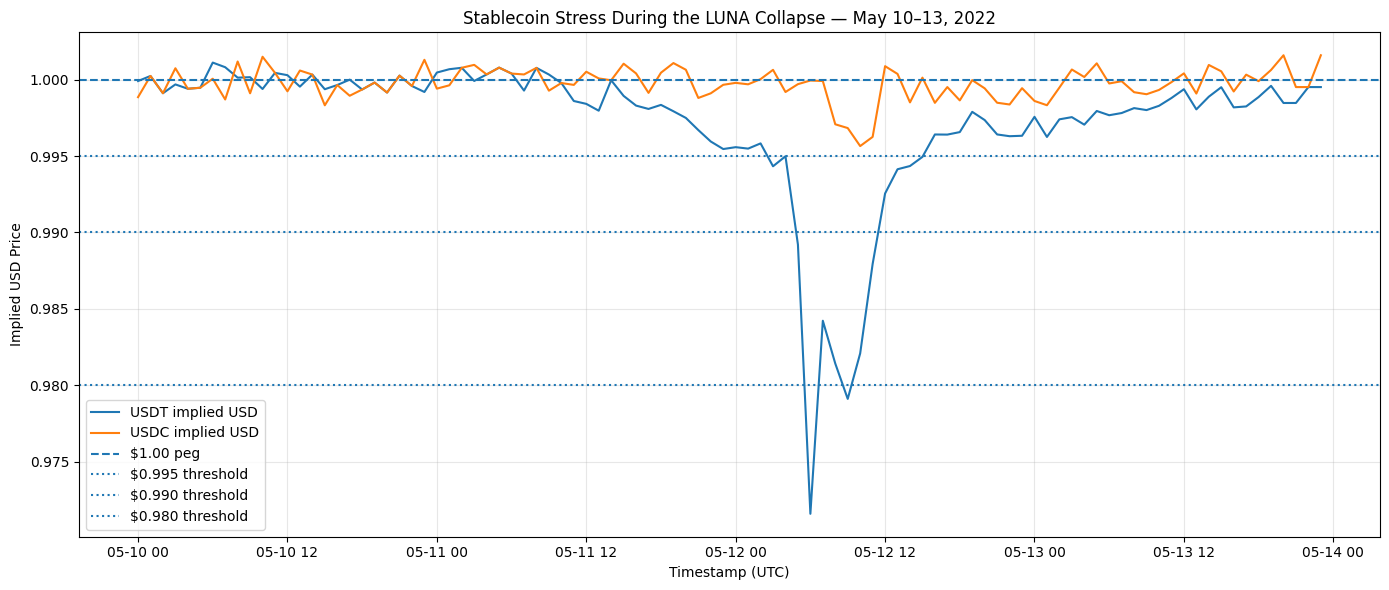

In [49]:
zoom = luna_stablecoin_fx[
    luna_stablecoin_fx["timestamp"].between(
        "2022-05-10 00:00:00+00:00",
        "2022-05-13 23:00:00+00:00"
    )
]

plt.figure(figsize=(14, 6))

plt.plot(
    zoom["timestamp"],
    zoom["usdt_usd_implied"],
    label="USDT implied USD"
)

plt.plot(
    zoom["timestamp"],
    zoom["usdc_usd_implied"],
    label="USDC implied USD"
)

plt.axhline(
    1.0,
    linestyle="--",
    label="$1.00 peg"
)

plt.axhline(
    0.995,
    linestyle=":",
    label="$0.995 threshold"
)

plt.axhline(
    0.990,
    linestyle=":",
    label="$0.990 threshold"
)

plt.axhline(
    0.980,
    linestyle=":",
    label="$0.980 threshold"
)

plt.title("Stablecoin Stress During the LUNA Collapse — May 10–13, 2022")
plt.xlabel("Timestamp (UTC)")
plt.ylabel("Implied USD Price")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Stablecoin Stability Finding

During the LUNA crisis, USDT experienced a clear but temporary deviation from its intended $1 value, while USDC remained considerably more stable.

USDT reached a minimum implied value of approximately **$0.9716**, or about **2.84% below the $1 target**.

It also remained below the selected $0.995 tolerance level for multiple consecutive hourly observations before recovering.

USDC did not show the same degree of instability during the selected event window.

For the modelled operational balance, this means that converting volatile crypto into USDT reduced direct BTC/ETH exposure, but did not completely remove valuation risk.

The LUNA case therefore demonstrates that **a stablecoin can still experience temporary peg stress even when the original source of the crisis is another stablecoin**.

## 5. LUNA Case Conclusion

The LUNA collapse developed during an already weakening crypto market and intensified into a broader BTC and ETH sell-off.

For the modelled payment scenario, the important result appears in the stablecoin layer.

USDT reduced direct exposure to the much larger BTC and ETH price movements, but it did not remain perfectly stable. During the crisis, USDT temporarily moved below its intended $1 value before recovering.

USDC remained more stable during the same period, showing that different stablecoins can respond differently to the same broader market event.

This case therefore adds the first limitation to the modelled balance-management strategy:

> **Converting volatile crypto into a stablecoin can reduce direct market-price exposure, but it does not eliminate stablecoin-specific valuation and contagion risk.**